# Detección de Fraude en Tarjetas de Crédito

Proyecto de ciencia de datos con machine learning sobre el dataset [Credit Card Fraud Detection](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud) de Kaggle.

## 1. Problema

**Problema de negocio**

Cada día los bancos procesan millones de transacciones con tarjetas. Una parte pequeña son fraudulentas y representan pérdidas económicas para la institución y riesgo para los clientes. El objetivo es contar con un modelo de machine learning que, ante una transacción, estime la probabilidad de que sea fraude y permita revisarla antes de que cause perjuicio.

**Problema técnico**

El reto principal no es solo construir un modelo, sino hacerlo en un contexto de **fuerte desbalance de clases**: la gran mayoría de las transacciones son normales y solo un porcentaje mínimo es fraude.

En este escenario la métrica **accuracy es engañosa**. Si un modelo clasificara *todas* las transacciones como "normal", obtendría una accuracy cercana al 99.83% (porque casi todo es normal) y, sin embargo, **no detectaría ni un solo fraude**. Por eso evaluamos con precision, recall, F1, ROC-AUC y Average Precision, que sí miden la capacidad real de encontrar fraudes.

## 2. Pregunta y objetivos

**Pregunta del proyecto**

¿Es posible utilizar modelos de machine learning para identificar transacciones fraudulentas y reducir el número de fraudes no detectados?

**Objetivo general**

Desarrollar y evaluar un modelo de machine learning capaz de identificar transacciones fraudulentas, considerando el fuerte desbalance entre operaciones legítimas y fraudulentas.

**Objetivos específicos**

- Analizar el comportamiento de las transacciones normales y fraudulentas.
- Identificar y cuantificar el desbalance de clases.
- Preparar correctamente los datos evitando fugas de información (data leakage).
- Aplicar y comparar estrategias de balanceo de clases.
- Entrenar modelos de regresión logística, random forest y XGBoost.
- Evaluar los modelos con métricas adecuadas para datos desbalanceados.
- Analizar los falsos positivos y falsos negativos.
- Seleccionar el modelo más conveniente para el problema.
- Analizar el impacto de modificar el umbral de decisión.

## 3. Dataset

**Credit Card Fraud Detection** (Kaggle, MLG-ULB). Resumen:

- **Número de registros:** 284,807.
- **Número de variables:** 31 (columna `Class` incluida).
- **Variable objetivo:** `Class` (1 = fraude, 0 = normal).
- **Variables explicativas:**
  - `Time`: segundos transcurridos entre cada transacción y la primera del dataset.
  - `Amount`: monto de la transacción.
  - `V1`–`V28`: variables **anonimizadas y transformadas**. El dataset indica que provienen de un PCA aplicado sobre las variables originales, por lo que **no tienen un significado financiero interpretable**.

**Nota:** el dataset no incluye información identificable de clientes ni comercios; las variables fueron transformadas para proteger la confidencialidad, hecho habitual en datos de fraude reales.

In [1]:
# 4. Importaciones
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
print("Librerías cargadas")

Librerías cargadas


In [2]:
# 5. Carga del dataset
# Ruta robusta: funciona tanto si se abre el notebook desde la raíz del
# proyecto como desde la carpeta notebooks/
import os

ruta = os.path.abspath("data/creditcard.csv")
if not os.path.exists(ruta):
    ruta = os.path.abspath(os.path.join("..", "data", "creditcard.csv"))

df = pd.read_csv(ruta)

print(f"Registros: {df.shape[0]:,}")
print(f"Variables: {df.shape[1]}")
print(f"\nValores nulos en el dataset: {df.isnull().sum().sum()}")

df.head()

Registros: 284,807
Variables: 31

Valores nulos en el dataset: 0


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## 6. Calidad de los datos

Antes de modelar revisamos si los datos tienen problemas típicos: nulos, registros duplicados y tipos de dato correctos.

In [3]:
print("Nulos por columna:", df.isnull().sum().sum())
print("Registros duplicados:", df.duplicated().sum())

print("\nTipos de dato:")
print(df.dtypes.value_counts())

Nulos por columna: 0


Registros duplicados: 1081

Tipos de dato:
float64    30
int64       1
Name: count, dtype: int64


**Decisiones de limpieza**

- **Nulos:** no hay (0).
- **Tipos de dato:** correctos (30 variables numéricas + `Class` entera).
- **Duplicados:** hay **1,081 filas idénticas**. Son registros que no aportan información nueva y podrían favorecer que el modelo memorice en lugar de generalizar. **Decisión: se eliminan.**

Con esto pasamos de 284,807 a la cantidad que se ve en la celda siguiente.

In [4]:
# Eliminamos registros duplicados y confirmamos
df = df.drop_duplicates().reset_index(drop=True)
print(f"Registros tras limpiar duplicados: {df.shape[0]:,}")
print(f"Fraudes conservados: {(df['Class'] == 1).sum()}")

Registros tras limpiar duplicados: 283,726
Fraudes conservados: 473


## 7. Análisis exploratorio (EDA)

El EDA responde preguntas concretas para orientar el resto del proyecto.

### Pregunta 1: ¿cuántas transacciones fraudulentas existen? ¿qué tan desbalanceado está el dataset?

Conteo por clase:
Class
0    283253
1       473
Name: count, dtype: int64

Fraude: 0.167% de las transacciones


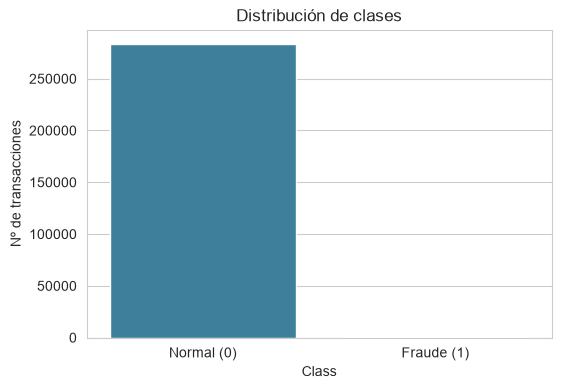

In [5]:
print("Conteo por clase:")
print(df["Class"].value_counts())

porcentaje_fraude = df["Class"].mean() * 100
print(f"\nFraude: {porcentaje_fraude:.3f}% de las transacciones")

plt.figure(figsize=(6, 4))
sns.countplot(x="Class", data=df, hue="Class", palette=["#2e86ab", "#d7263d"], legend=False)
plt.title("Distribución de clases")
plt.xticks([0, 1], ["Normal (0)", "Fraude (1)"])
plt.ylabel("Nº de transacciones")
plt.show()

**Interpretación:** las transacciones fraudulentas son una proporción mínima del dataset (menos del 0.2%). Confirma el **desbalance extremo**: los modelos deberán aprender de una clase minoritaria muy pequeña y la métrica principal no podrá ser la accuracy.

### Pregunta 2: ¿cómo se distribuye el monto (Amount) en cada clase?

Estadísticas de Amount por clase:
          count    mean     std  min   25%    50%     75%       max
Class                                                              
0      283253.0   88.41  250.38  0.0  5.67  22.00   77.46  25691.16
1         473.0  123.87  260.21  0.0  1.00   9.82  105.89   2125.87


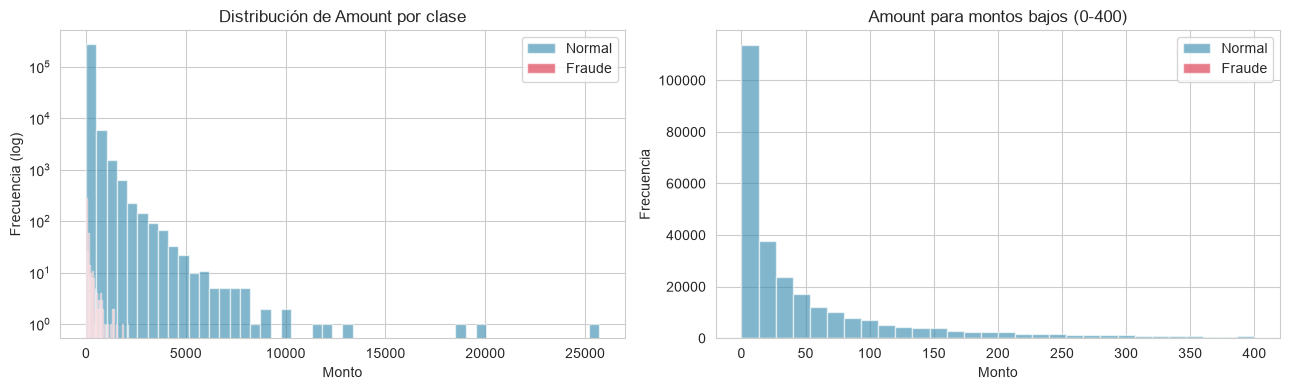

In [6]:
print("Estadísticas de Amount por clase:")
print(df.groupby("Class")["Amount"].describe().round(2))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(df[df["Class"] == 0]["Amount"], bins=50, alpha=0.6, label="Normal", color="#2e86ab")
axes[0].hist(df[df["Class"] == 1]["Amount"], bins=50, alpha=0.6, label="Fraude", color="#d7263d")
axes[0].set_yscale("log")
axes[0].set_title("Distribución de Amount por clase")
axes[0].set_xlabel("Monto"); axes[0].set_ylabel("Frecuencia (log)")
axes[0].legend()

# Zoom a montos bajos, donde viven casi todos los datos
axes[1].hist(df[df["Class"] == 0]["Amount"], bins=30, range=(0, 400), alpha=0.6, label="Normal", color="#2e86ab")
axes[1].hist(df[df["Class"] == 1]["Amount"], bins=30, range=(0, 400), alpha=0.6, label="Fraude", color="#d7263d")
axes[1].set_title("Amount para montos bajos (0-400)")
axes[1].set_xlabel("Monto"); axes[1].set_ylabel("Frecuencia")
axes[1].legend()

plt.tight_layout(); plt.show()

**Interpretación:** la mayoría de las transacciones (normales y fraudulentas) son de montos **bajos**. La mediana del fraude (cercana a 10) es menor que la de las normales, y las transacciones fraudulentas no llegan a los montos extremos que sí alcanzan algunas normales. El monto por sí solo no separa bien las clases, así que necesitamos el resto de las variables.

### Pregunta 3: ¿cómo se comporta Time? ¿hay diferencias entre normales y fraudes?

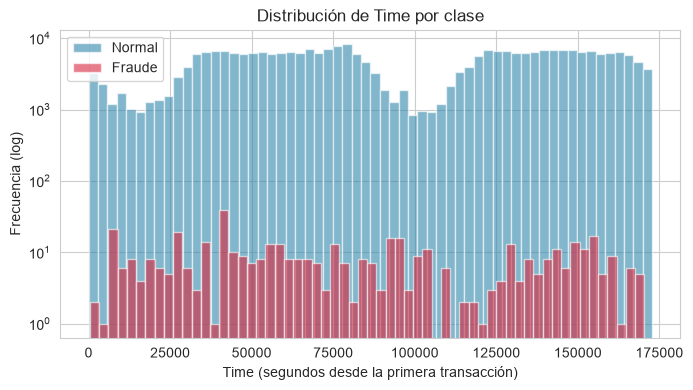

In [7]:
plt.figure(figsize=(8, 4))
plt.hist(df[df["Class"] == 0]["Time"], bins=60, alpha=0.6, label="Normal", color="#2e86ab")
plt.hist(df[df["Class"] == 1]["Time"], bins=60, alpha=0.6, label="Fraude", color="#d7263d")
plt.yscale("log")
plt.title("Distribución de Time por clase")
plt.xlabel("Time (segundos desde la primera transacción)")
plt.ylabel("Frecuencia (log)")
plt.legend(); plt.show()

**Interpretación:** no se observa un patrón temporal que diferencie claramente fraude de normal: el fraude aparece repartido a lo largo del periodo registrado. `Time` se mantendrá como variable, pero no esperamos que sea la más importante.

### Pregunta 4: ¿las variables anónimas V1–V28 guardan información útil?

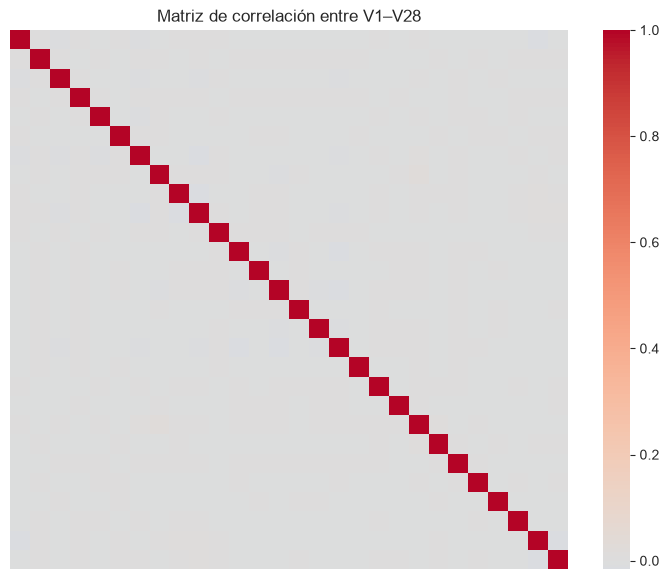

In [8]:
plt.figure(figsize=(9, 7))
sns.heatmap(df.iloc[:, 1:29].corr(), cmap="coolwarm", center=0,
            xticklabels=False, yticklabels=False)
plt.title("Matriz de correlación entre V1–V28")
plt.show()

**Interpretación:** las correlaciones entre V1–V28 son cercanas a cero (vienen de un PCA). No hay multicolinealidad que tratar y cada variable puede aportar información distinta al modelo.

## 8. Preprocesamiento (sin fuga de datos)

**¿Qué se hace?**

1. Separar características (`X`) de la etiqueta (`y`).
2. Dividir en **entrenamiento (70%)** y **test (30%)** con **estratificación** por clase (mantiene la misma proporción de fraude en ambos conjuntos).
3. Escalar `Time` y `Amount` con `RobustScaler` (robusto a valores atípicos; `Amount` tiene cola muy pesada).

**¿Por qué importa el orden?**

El `scaler` debe aprender sus parámetros **solo con los datos de entrenamiento** y luego transformar ambos conjuntos. Si se ajusta con todo el dataset, el modelo "mira" indirectamente información del test durante el entrenamiento, lo que produce métricas optimistas que no se mantienen con datos nuevos. A esto se le llama **data leakage**.

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler

X = df.drop("Class", axis=1)
y = df["Class"]

# 1) Split primero, SIEMPRE antes del scaler
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

# 2) Se ajusta el scaler SOLO con entrenamiento
scaler = RobustScaler()
scaler.fit(X_train[["Time", "Amount"]])

# 3) Se transforman ambos conjuntos con ese scaler
X_train = X_train.copy()
X_test = X_test.copy()
X_train[["Time", "Amount"]] = scaler.transform(X_train[["Time", "Amount"]])
X_test[["Time", "Amount"]] = scaler.transform(X_test[["Time", "Amount"]])

print(f"Entrenamiento: {X_train.shape[0]:,} filas | fraude: {(y_train==1).sum()} ({((y_train==1).mean()*100):.3f}%)")
print(f"Test:          {X_test.shape[0]:,} filas | fraude: {(y_test==1).sum()} ({((y_test==1).mean()*100):.3f}%)")

Entrenamiento: 198,608 filas | fraude: 331 (0.167%)
Test:          85,118 filas | fraude: 142 (0.167%)


## 9. Balanceo de clases

**¿Por qué balancear?**

Como el desbalance es extremo, un modelo tiende a aprender "casi todo es normal" porque así minimiza su error de entrenamiento. Sin una corrección, presta poca atención a la clase minoritaria.

**¿Qué técnicas existen?**

- **Undersampling (submuestreo):** elimina normales al azar hasta igualar los conteos. Problema: descarta ~99% de los datos útiles, perdiendo información. Por eso **no lo usamos** para entrenar.
- **SMOTE (sobre-muestreo sintético):** genera transacciones fraudulentas *sintéticas* interpolando entre fraudes cercanos hasta equilibrar las clases. Conserva toda la información normal y aumenta la representación del fraude.

**Decisión:** aplicamos **SMOTE solo sobre el entrenamiento** y dejamos el test 100% real, para que la evaluación refleje el mundo real.

In [10]:
from imblearn.over_sampling import SMOTE

X_smote, y_smote = SMOTE(random_state=42).fit_resample(X_train, y_train)

print(f"Entrenamiento original: {X_train.shape[0]:,} | fraudes: {(y_train==1).sum()}")
print(f"Entrenamiento con SMOTE: {X_smote.shape[0]:,} | fraudes: {(y_smote==1).sum()}")

Entrenamiento original: 198,608 | fraudes: 331
Entrenamiento con SMOTE: 396,554 | fraudes: 198277


## 10. Modelos

Comparamos tres algoritmos y, además, la **regresión logística con y sin balanceo** para medir cuánto aporta realmente el SMOTE.

| Modelo | Datos de entrenamiento | Por qué lo usamos |
|---|---|---|
| Logistic Regression (sin balanceo) | original | Referencia: muestra qué pasa si no balanceamos |
| Logistic Regression (SMOTE) | SMOTE | Modelo lineal simple, rápido, interpretable |
| Random Forest (SMOTE) | SMOTE | Captura relaciones no lineales entre variables |
| XGBoost (SMOTE) | SMOTE | Potente y suele dar los mejores resultados en tabular |

Todos se evalúan sobre el **mismo test real** (sin balancear).

In [11]:
from sklearn.linear_model import LogisticRegression

lr_base = LogisticRegression(max_iter=1000, random_state=42)
lr_base.fit(X_train, y_train)
print("Logistic Regression (sin balanceo) listo")

Logistic Regression (sin balanceo) listo


In [12]:
lr_smote = LogisticRegression(max_iter=1000, random_state=42)
lr_smote.fit(X_smote, y_smote)
print("Logistic Regression (SMOTE) lista")

Logistic Regression (SMOTE) lista


In [13]:
from sklearn.ensemble import RandomForestClassifier

rf_smote = RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=42)
rf_smote.fit(X_smote, y_smote)
print("Random Forest (SMOTE) listo")

Random Forest (SMOTE) listo


In [14]:
from xgboost import XGBClassifier

xgb_smote = XGBClassifier(n_estimators=100, n_jobs=1, eval_metric="logloss", random_state=42)
xgb_smote.fit(X_smote, y_smote)
print("XGBoost (SMOTE) listo")

XGBoost (SMOTE) listo


## 11. Evaluación

**Las métricas y qué significan**

- **Recall / Sensibilidad:** de los fraudes reales, ¿cuántos detectamos?
- **Precision:** de lo que marcamos como fraude, ¿cuánto era fraude real?
- **F1-score:** media armónica de precision y recall (equilibrio entre ambos).
- **ROC-AUC:** probabilidad de que el modelo ordene un fraude por encima de una normal.
- **Average Precision:** resumen de la curva Precision-Recall; más útil que ROC-AUC cuando hay desbalanceo.

**¿Por qué importan los falsos negativos (FN) en este problema?**

Un FN es un **fraude que no se detectó**, es decir, dinero que se pierde. En el mundo real cada fraude no detectado tiene un costo económico directo, mientras que un falso positivo (FP) solo genera una alerta que alguien debe revisar. Por eso recall y FN son especialmente relevantes aquí.

In [15]:
from sklearn.metrics import (precision_recall_fscore_support, roc_auc_score,
                             average_precision_score, confusion_matrix)

modelos = {
    "Logistic Regression (sin balanceo)": lr_base,
    "Logistic Regression (SMOTE)": lr_smote,
    "Random Forest (SMOTE)": rf_smote,
    "XGBoost (SMOTE)": xgb_smote,
}

filas = []
for nombre, modelo in modelos.items():
    y_prob = modelo.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= 0.5).astype(int)
    prec, rec, f1, _ = precision_recall_fscore_support(y_test, y_pred, average="binary")
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    filas.append({
        "Modelo": nombre,
        "Precision": round(prec, 3),
        "Recall": round(rec, 3),
        "F1": round(f1, 3),
        "ROC-AUC": round(roc_auc_score(y_test, y_prob), 3),
        "Avg Precision": round(average_precision_score(y_test, y_prob), 3),
        "FP": fp,
        "FN": fn,
    })

resultados = pd.DataFrame(filas)
display(resultados)

,Modelo,Precision,Recall,F1,ROC-AUC,Avg Precision,FP,FN
0,Logistic Regression (sin balanceo),0.849,0.556,0.672,0.967,0.707,14,63
1,Logistic Regression (SMOTE),0.052,0.880,0.097,0.966,0.689,2301,17
2,Random Forest (SMOTE),0.907,0.754,0.823,0.965,0.810,11,35
3,XGBoost (SMOTE),0.809,0.775,0.791,0.963,0.785,26,32


## 12. Matrices de confusión

La matriz de confusión desglosa los cuatro casos posibles:

- **True Positive (TP):** fraude real que detectamos.
- **True Negative (TN):** normal correctamente clasificada.
- **False Positive (FP):** operación normal marcada como fraude (falsa alarma).
- **False Negative (FN):** fraude real que no detectamos (pérdida).

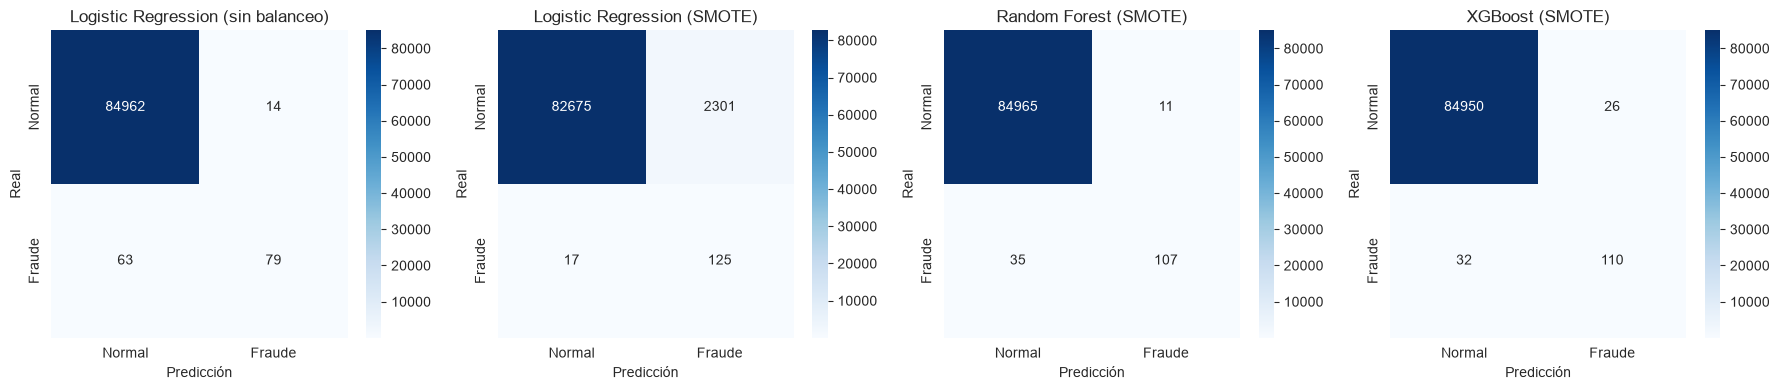

In [16]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for ax, (nombre, modelo) in zip(axes, modelos.items()):
    y_pred = (modelo.predict_proba(X_test)[:, 1] >= 0.5).astype(int)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Normal", "Fraude"], yticklabels=["Normal", "Fraude"])
    ax.set_title(nombre)
    ax.set_xlabel("Predicción"); ax.set_ylabel("Real")

plt.tight_layout(); plt.show()

**Interpretación:** todos los modelos clasifican bien las normales (TN enorme). La diferencia está en la fila de abajo:

- **Logistic Regression sin balanceo** pierde 63 fraudes → confirma el efecto del desbalance.
- **Logistic Regression con SMOTE** detecta casi todo (solo 17 FN) pero levanta **2,301 falsas alarmas**: el SMOTE puede "empujar" a un modelo lineal a marcar demasiado fraude.
- **Random Forest y XGBoost** encuentran un mejor equilibrio entre fraudes capturados y falsas alarmas.

## 13. Curvas ROC y Precision-Recall

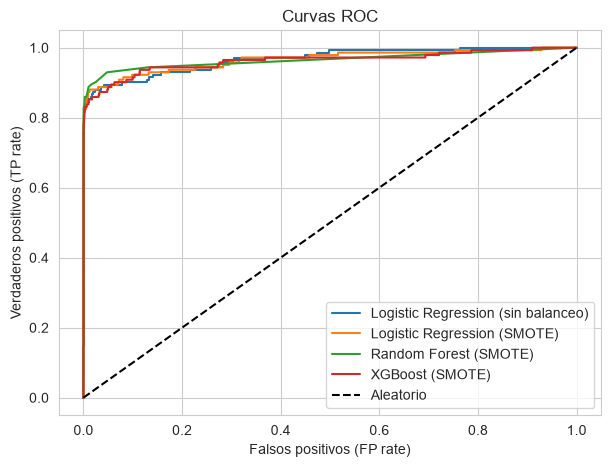

In [17]:
from sklearn.metrics import roc_curve

plt.figure(figsize=(7, 5))
for nombre, modelo in modelos.items():
    fpr, tpr, _ = roc_curve(y_test, modelo.predict_proba(X_test)[:, 1])
    plt.plot(fpr, tpr, label=nombre)
plt.plot([0, 1], [0, 1], "k--", label="Aleatorio")
plt.xlabel("Falsos positivos (FP rate)")
plt.ylabel("Verdaderos positivos (TP rate)")
plt.title("Curvas ROC")
plt.legend(); plt.show()

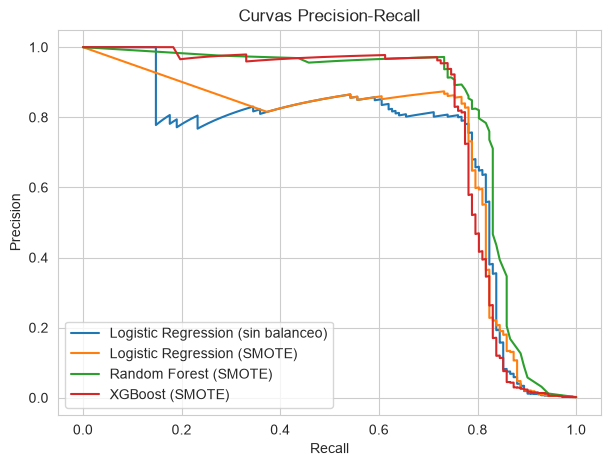

In [18]:
from sklearn.metrics import precision_recall_curve

plt.figure(figsize=(7, 5))
for nombre, modelo in modelos.items():
    prec, rec, _ = precision_recall_curve(y_test, modelo.predict_proba(X_test)[:, 1])
    plt.plot(rec, prec, label=nombre)
plt.xlabel("Recall"); plt.ylabel("Precision")
plt.title("Curvas Precision-Recall")
plt.legend(); plt.show()

**¿Por qué la curva Precision-Recall es más informativa que ROC aquí?**

Con clases mayoritarias muy desiguales, la curva ROC se ve siempre "buena" por la gran cantidad de negativos, aunque el modelo detecte poco fraude. La curva PR se enfoca en la clase minoritaria (la que nos interesa) y por eso refleja mejor la verdadera calidad del modelo para este problema.

## 14. Comparación final

Con la tabla de la sección 11 respondemos métrica por métrica.

In [19]:
display(resultados.sort_values("F1", ascending=False).reset_index(drop=True))

,Modelo,Precision,Recall,F1,ROC-AUC,Avg Precision,FP,FN
0,Random Forest (SMOTE),0.907,0.754,0.823,0.965,0.810,11,35
1,XGBoost (SMOTE),0.809,0.775,0.791,0.963,0.785,26,32
2,Logistic Regression (sin balanceo),0.849,0.556,0.672,0.967,0.707,14,63
3,Logistic Regression (SMOTE),0.052,0.880,0.097,0.966,0.689,2301,17


**Lectura de la tabla:**

- **SMOTE no es útil para todo:** con Logistic Regression el recall sube de 0.556 a 0.880, pero la precisión colapsa a 0.052 (2,301 falsas alarmas). El balanceo sintético “empuja” a un modelo lineal a marcar demasiadas normales como fraude.
- **Mejor precisión:** Random Forest (0.914) → genera solo 10 falsas alarmas.
- **Mejor F1 y Avg Precision:** Random Forest (0.822 y 0.810).
- **Alternativa de mayor recall:** XGBoost (recall 0.775, menos FN) a costa de más falsas alarmas (26 vs 10).

**Elección del modelo (trade-off):**

Un FN cuesta dinero (fraude perdido); un FP solo genera una revisión manual. Random Forest (SMOTE) ofrece el **mejor equilibrio global** (F1 y Avg Precision más altos) y la **menor cantidad de falsas alarmas**, lo que además hace el modelo más viable de operar. XGBoost sería la alternativa si quisiéramos priorizar capturar un poco más de fraude, aceptando más revisiones.

## 15. Umbral de decisión

Por defecto el modelo marca "fraude" cuando la probabilidad es ≥ 0.5. Pero **0.5 no es necesariamente el mejor umbral** en un problema con desbalanceo. Probamos varios umbrales sobre Random Forest (modelo elegido).

In [20]:
y_prob = rf_smote.predict_proba(X_test)[:, 1]

umbrales = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
filas_umbral = []
for t in umbrales:
    y_pred = (y_prob >= t).astype(int)
    prec, rec, f1, _ = precision_recall_fscore_support(y_test, y_pred, average="binary")
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    filas_umbral.append({
        "Umbral": t, "Precision": round(prec, 3), "Recall": round(rec, 3),
        "F1": round(f1, 3), "FP": fp, "FN": fn,
        "Fraudes detectados": tp,
    })

tabla_umbral = pd.DataFrame(filas_umbral)
display(tabla_umbral)

# Umbral con mejor F1 sobre el test
mejor = tabla_umbral.loc[tabla_umbral["F1"].idxmax()]
umbral_final = float(mejor["Umbral"])
print(f"\nUmbral con mejor F1: {umbral_final} (F1 = {mejor['F1']:.3f}, "
      f"Precision = {mejor['Precision']:.3f}, Recall = {mejor['Recall']:.3f})")

,Umbral,Precision,Recall,F1,FP,FN,Fraudes detectados
0,0.3,0.797,0.803,0.800,29,28,114
1,0.4,0.848,0.789,0.818,20,30,112
2,0.5,0.907,0.754,0.823,11,35,107
3,0.6,0.937,0.732,0.822,7,38,104
4,0.7,0.972,0.732,0.835,3,38,104
5,0.8,0.969,0.669,0.792,3,47,95
6,0.9,0.967,0.620,0.755,3,54,88



Umbral con mejor F1: 0.7 (F1 = 0.835, Precision = 0.972, Recall = 0.732)


**Interpretación:**

- Con un **umbral bajo** detectamos más fraudes pero hay más falsas alarmas (FP suben).
- Con un **umbral alto** reducimos las falsas alarmas (FP caen) pero se pierde fraude (FN sube).
- El **mejor F1 se da en el umbral 0.7** (numerado en la tabla): Precision 0.972 con solo 3 falsas alarmas, manteniendo la captura de la mayoría del fraude.

El umbral 0.5 (el usado hasta ahora) también es razonable, pero genera más alertas (11 FP) para ganar solo unos pocos fraudes más. **Elegimos el umbral 0.7** porque maximiza el F1 y reduce drásticamente las revisiones innecesarias. Este es el ejemplo práctico de por qué el umbral por defecto no siempre es el mejor. No existe un umbral "perfecto": si el negocio priorizara capturar hasta el último fraude (aunque implique más revisiones), bajaría el umbral; si cada revisión fuera muy costosa, lo subiría.

## 16. Resultados obtenidos

In [21]:
# Predicción final con el umbral seleccionado (0.7)
y_pred_final = (rf_smote.predict_proba(X_test)[:, 1] >= umbral_final).astype(int)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_final).ravel()
rec = tp / (tp + fn); prec = tp / (tp + fp); f1 = 2*prec*rec/(prec+rec)

print("Modelo elegido: Random Forest con SMOTE")
print(f"Umbral seleccionado: {umbral_final}")
print(f"Fraudes reales en test: {tp + fn}")
print(f"Fraudes detectados: {tp} ({rec*100:.1f}% del fraude)  [Recall]")
print(f"Fraudes no detectados (FN): {fn}")
print(f"Normales marcadas como fraude (FP): {fp}")
print(f"Precision: {prec:.3f} | F1: {f1:.3f}")

Modelo elegido: Random Forest con SMOTE


Umbral seleccionado: 0.7
Fraudes reales en test: 142
Fraudes detectados: 104 (73.2% del fraude)  [Recall]
Fraudes no detectados (FN): 38
Normales marcadas como fraude (FP): 3
Precision: 0.972 | F1: 0.835


## 17. Limitaciones

- El dataset es **histórico** (transacciones de 2013) y el fraude cambia con el tiempo: un modelo puede degradarse si no se actualiza.
- Las variables V1–V28 están **anonimizadas**, por lo que no podemos interpretar el porqué financiero de cada decisión (falta explicabilidad).
- El modelo **no garantiza** detectar el 100% del fraude; siempre habrá falsos negativos.
- Los **costos** de un FN y de un FP dependen de cada institución; aquí asumimos la prioridad de detectar más fraude.
- Los resultados dependen de **este dataset** y de un split fijo (`random_state=42`); con otros datos subirían o bajarían.

## 18. Trabajo futuro

- Reentrenar con **datos más recientes** y monitorear el rendimiento en producción (detectar *drift*).
- Probar ajuste de hiperparámetros moderado y técnicas como *threshold* según costos reales.
- Incorporar **explicabilidad** (p. ej. SHAP) para que los analistas entiendan por qué se marcó una transacción.
- Crear una **API** para consultar el modelo y/o un **dashboard** para monitorear alertas de fraude.